In [9]:
import matplotlib.pyplot as plt
import numpy as np

import meow as mw

In [29]:
def create_structures(length=10.0, input_width=0.45, output_width=1.0):
    oxide = mw.Structure(
        material=mw.silicon_oxide,
        geometry=mw.Prism(
            poly=np.array([(0, -2.1), (length, -2.1), (length, 2.1), (0, 2.1)]),
            h_min=-3.0,
            h_max=3.0,
            axis="y",
        ),
    )

    core = mw.Structure(
        material=mw.silicon,
        geometry=mw.Prism(
            poly=np.array(
                [
                    (0, -input_width / 2),
                    (length, -output_width / 2),
                    (length, output_width / 2),
                    (0, input_width / 2),
                ]
            ),
            h_min=0.0,
            h_max=0.22,
            axis="y",
        ),
    )

    return [oxide, core]


structures = create_structures(input_width=3, output_width=3)
mw.visualize(structures)

In [30]:
length = 10.0
num_cells = 1

cells = mw.create_cells(
    structures=structures,
    mesh=mw.Mesh2D(
        x=np.linspace(-2.0, 2.0, 121),
        y=np.linspace(-2.0, 2.0, 121),
    ),
    Ls=np.full(num_cells, length / num_cells),
)

env = mw.Environment(wl=1.55, T=25.0)
cross_sections = [mw.CrossSection.from_cell(cell=cell, env=env) for cell in cells]
modes = [mw.compute_modes(cs, num_modes=4) for cs in cross_sections]

print(f"Computed {len(modes)} mode sets with {len(modes[0])} modes in the first cell.")

Computed 1 mode sets with 4 modes in the first cell.


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (4).

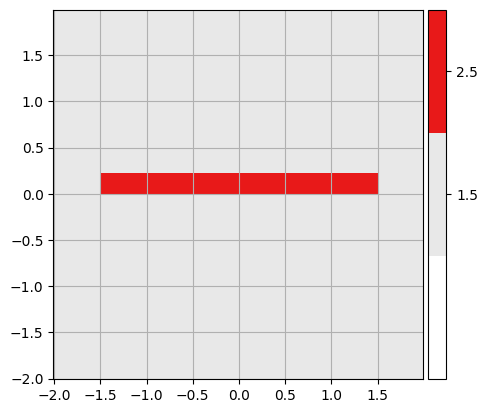

In [31]:
mw.visualize(cells[0])

In [32]:
z = np.linspace(cells[0].z_min, cells[-1].z_max, 500)
y = 0.0

field, x = mw.propagate_modes(modes, cells, y=y, z=z)
print(field.shape, x.shape)

(500, 120) (120,)


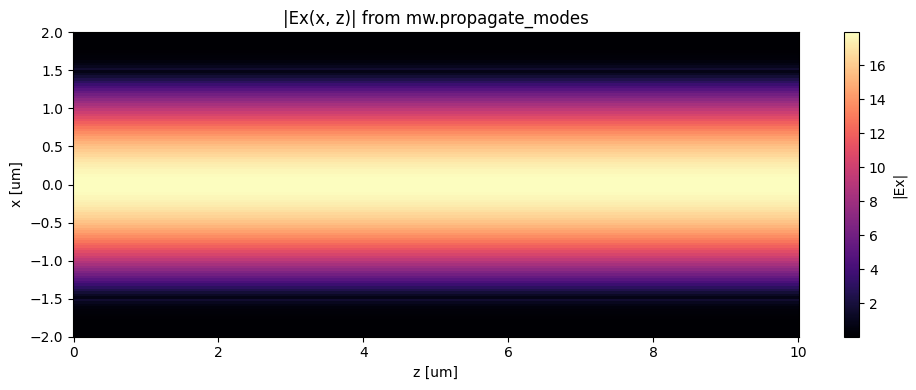

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(z, x, np.abs(field).T, shading="auto", cmap="magma")
ax.set_xlabel("z [um]")
ax.set_ylabel("x [um]")
ax.set_title("|Ex(x, z)| from mw.propagate_modes")
plt.colorbar(im, ax=ax, label="|Ex|")
plt.tight_layout()

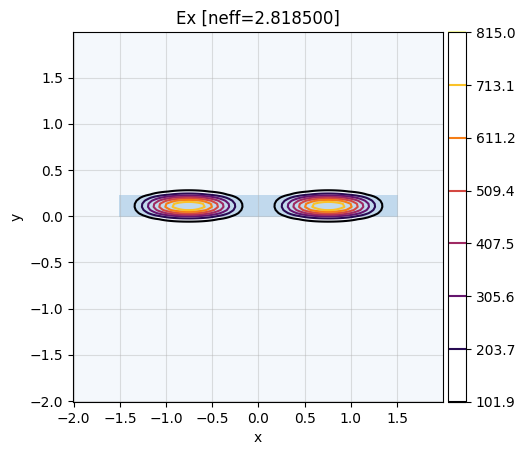

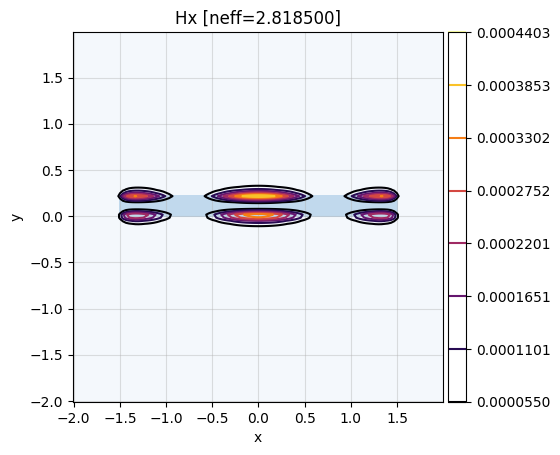

In [36]:
# show Ex component of the first mode (idx 0)
# of the first cell (idx 0):
mw.visualize(modes[0][1], fields=["Ex"])
# show Hx component of the second mode (idx 1)
# of the first cell (idx 0):
mw.visualize(modes[0][1], fields=["Hx"])

{'left@0': 0, 'left@1': 1, 'left@2': 2, 'left@3': 3, 'right@0': 4, 'right@1': 5, 'right@2': 6, 'right@3': 7}


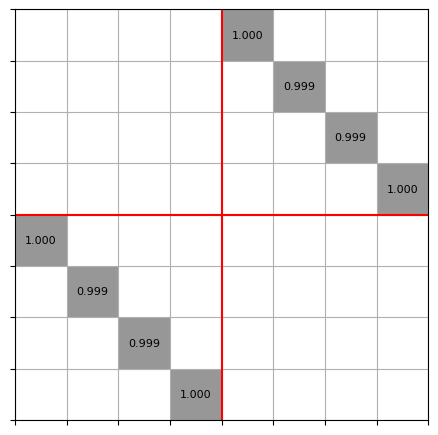

In [8]:
S, port_map = mw.compute_s_matrix(modes, cells=cells)
print(port_map)
mw.visualize((abs(S), port_map))

In [39]:
"""
2x2 MMI Splitter — meow-sim EME simulation (3 cells)
=====================================================
Cell layout (propagation along z):
  Cell 0 │ Cell 1       │ Cell 2
  ───────────────────────────────
  Input   │  MMI body    │ Output
  WGs     │  (multimode) │ WGs

Geometry (SOI, 220 nm slab):
  - Waveguide width  : 0.5 µm  (single-mode)
  - MMI width        : 6.0 µm  (multimode)
  - MMI length       : 26.0 µm (≈ 3Lπ/2 for 2×2 at 1550 nm)
  - Input/output wg
    access length    : 2.0 µm  (one cell each)
  - Input port offset: ±1.5 µm from centre
  - Output port offset: ±1.5 µm from centre
  - Core thickness   : 0.22 µm
  - BOX thickness    : 1.0 µm
  - Cladding         : oxide

Usage
-----
    pip install meow-sim[min]
    python mmi_2x2_meow.py
"""

import numpy as np
import meow as mw

# ── Simulation parameters ──────────────────────────────────────────────────
wavelength   = 1.55    # µm
temperature  = 25.0    # °C
num_modes    = 8       # enough to capture all guided MMI modes

# ── Geometry ───────────────────────────────────────────────────────────────
wg_w     = 0.5    # single-mode waveguide width  [µm]
wg_h     = 0.22   # waveguide (core) height       [µm]
mmi_w    = 6.0    # MMI multimode section width   [µm]
mmi_l    = 26.0   # MMI body length               [µm]
port_off = 1.5    # centre-to-port offset         [µm]  (for 2×2)
access_l = 2.0    # input / output cell length    [µm]

box_h    = 1.0    # buried oxide thickness        [µm]
clad_h   = 1.0    # top cladding thickness        [µm]

# Simulation window (x = lateral, y = vertical)
x_half = mmi_w / 2 + 1.0   # half-width of simulation window [µm]
y_min  = -box_h
y_max  =  wg_h + clad_h

# ── Mesh ───────────────────────────────────────────────────────────────────
mesh = mw.Mesh2D(
    x=np.linspace(-x_half, x_half, 200),
    y=np.linspace(y_min,   y_max,  100),
)

# ── Materials ──────────────────────────────────────────────────────────────
oxide   = mw.silicon_oxide    # SiO2
silicon = mw.silicon          # Si

# ── Helper: build structures for a given cross-section width ───────────────
def make_structures(core_width: float, z_start: float, z_end: float):
    """Return [cladding, BOX, core] for a section of given width."""
    # BOX (SiO2 below)
    box = mw.Structure(
        material=oxide,
        geometry=mw.Box(
            x_min=-x_half, x_max=x_half,
            y_min=y_min,   y_max=0.0,
            z_min=z_start, z_max=z_end,
        ),
    )
    # Top cladding (SiO2 above)
    clad = mw.Structure(
        material=oxide,
        geometry=mw.Box(
            x_min=-x_half, x_max=x_half,
            y_min=wg_h,    y_max=y_max,
            z_min=z_start, z_max=z_end,
        ),
    )
    # Silicon core
    core = mw.Structure(
        material=silicon,
        geometry=mw.Box(
            x_min=-core_width / 2, x_max=core_width / 2,
            y_min=0.0,             y_max=wg_h,
            z_min=z_start,         z_max=z_end,
        ),
    )
    return [box, clad, core]


# ── Structures for each cell ────────────────────────────────────────────────
# Cell 0: Input section — two access waveguides separated by port_off*2
# For the input cross-section we model BOTH waveguides side by side.
# We represent this with two separate core boxes.

def make_two_wg_structures(z_start, z_end):
    """Two single-mode waveguides at ±port_off (input / output section)."""
    box = mw.Structure(
        material=oxide,
        geometry=mw.Box(
            x_min=-x_half, x_max=x_half,
            y_min=y_min,   y_max=0.0,
            z_min=z_start, z_max=z_end,
        ),
    )
    clad = mw.Structure(
        material=oxide,
        geometry=mw.Box(
            x_min=-x_half, x_max=x_half,
            y_min=wg_h,    y_max=y_max,
            z_min=z_start, z_max=z_end,
        ),
    )
    core_left = mw.Structure(
        material=silicon,
        geometry=mw.Box(
            x_min=-port_off - wg_w / 2, x_max=-port_off + wg_w / 2,
            y_min=0.0,                   y_max=wg_h,
            z_min=z_start,               z_max=z_end,
        ),
    )
    core_right = mw.Structure(
        material=silicon,
        geometry=mw.Box(
            x_min= port_off - wg_w / 2, x_max= port_off + wg_w / 2,
            y_min=0.0,                   y_max=wg_h,
            z_min=z_start,               z_max=z_end,
        ),
    )
    return [box, clad, core_left, core_right]


# z-coordinates of the three sections
z0, z1 = 0.0,        access_l
z1, z2 = access_l,   access_l + mmi_l
z2, z3 = access_l + mmi_l, access_l + mmi_l + access_l

structs_input  = make_two_wg_structures(z0, z1)
structs_mmi    = make_structures(mmi_w, z1, z2)
structs_output = make_two_wg_structures(z2, z3)

# ── Create cells (3 total) ─────────────────────────────────────────────────
cells = [
    mw.Cell(
        structures=structs_input,
        mesh=mesh,
        z_min=z0, z_max=z1,
    ),
    mw.Cell(
        structures=structs_mmi,
        mesh=mesh,
        z_min=z1, z_max=z2,
    ),
    mw.Cell(
        structures=structs_output,
        mesh=mesh,
        z_min=z2, z_max=z3,
    ),
]

print(f"Total cells : {len(cells)}")
print(f"Cell lengths: {[c.z_max - c.z_min for c in cells]} µm")

# ── Environment ────────────────────────────────────────────────────────────
env = mw.Environment(wl=wavelength, T=temperature)

# ── Cross-sections ─────────────────────────────────────────────────────────
css = [mw.CrossSection.from_cell(cell=c, env=env) for c in cells]

# ── Compute modes ──────────────────────────────────────────────────────────
print(f"\nComputing {num_modes} modes for each of the {len(css)} cross-sections…")
all_modes = []
for i, cs in enumerate(css):
    modes = mw.compute_modes(cs, num_modes=num_modes)
    all_modes.append(modes)
    neffs = [f"{m.neff:.4f}" for m in modes]
    print(f"  Cell {i}: neff = {neffs}")

# ── Compute S-matrix via EME ───────────────────────────────────────────────
print("\nComputing S-matrix…")
S, port_map = mw.compute_s_matrix(all_modes, cells=cells)

print("\nPort map:", port_map)
print(f"S-matrix shape: {S.shape}  (2 × num_modes × 2 × num_modes)")

# ── Extract key S-parameters ───────────────────────────────────────────────
# Ports 0 = left (input) interface, 1 = right (output) interface
# Mode 0 is the fundamental TE mode of the access waveguide.

# Transmission (left TE0 → right TE0 at both output waveguides)
T_thru = np.abs(S[1, 0]) ** 2   # output port, mode 0, from input port, mode 0
T_cross= np.abs(S[1, 1]) ** 2   # output port, mode 1, from input port, mode 0
R_back = np.abs(S[0, 0]) ** 2   # reflection to input, mode 0

print("\n── S-parameter summary (TE0 excitation at port 0) ──")
print(f"  |S(out_mode0, in_mode0)|² = {T_thru:.4f}  (bar / thru)")
print(f"  |S(out_mode1, in_mode0)|² = {T_cross:.4f}  (cross)")
print(f"  |S(in_mode0,  in_mode0)|² = {R_back:.4f}  (back-reflection)")
print(f"  Total power tracked: {T_thru + T_cross + R_back:.4f}")

print("\n✓ Simulation complete.")

Total cells : 3
Cell lengths: [2.0, 26.0, 2.0] µm

Computing 8 modes for each of the 3 cross-sections…
  Cell 0: neff = ['2.4196+0.0000j', '2.4196+0.0000j', '2.2542+0.0000j', '2.2542+0.0000j', '2.2336+0.0000j', '2.2336+0.0000j', '2.2331+0.0000j', '2.2330+0.0000j']
  Cell 1: neff = ['2.8474+0.0000j', '2.8430+0.0000j', '2.8393+0.0000j', '2.8368+0.0000j', '2.8351+0.0000j', '2.8340+0.0000j', '2.8334+0.0000j', '2.8331+0.0000j']
  Cell 2: neff = ['2.4196+0.0000j', '2.4196+0.0000j', '2.2542+0.0000j', '2.2542+0.0000j', '2.2336+0.0000j', '2.2336+0.0000j', '2.2331+0.0000j', '2.2330+0.0000j']

Computing S-matrix…

Port map: {'left@0': 0, 'left@1': 1, 'left@2': 2, 'left@3': 3, 'left@4': 4, 'left@5': 5, 'left@6': 6, 'left@7': 7, 'right@0': 8, 'right@1': 9, 'right@2': 10, 'right@3': 11, 'right@4': 12, 'right@5': 13, 'right@6': 14, 'right@7': 15}
S-matrix shape: (16, 16)  (2 × num_modes × 2 × num_modes)

── S-parameter summary (TE0 excitation at port 0) ──
  |S(out_mode0, in_mode0)|² = 0.0000  (bar /

In [76]:
import numpy as np
import meow as mw



# ----------------------------
# Geometry parameters (microns)
# ----------------------------
wl = 1.55
T = 25.0
si_t = 0.22

# simulation window
x_span = 8.0
y_min, y_max = -2.0, 2.0

# waveguide widths / positions
wg_w = 1.25
port_pitch = 2.0           # separation between the two access guides
mmi_w = 4.0                # multimode section width

# lengths of the 3 cells
L_in = 2.0
L_mmi = 100.0
L_out = 2.0
Ls = np.array([L_in, L_mmi, L_out])

z0 = 0.0
z1 = z0 + L_in
z2 = z1 + L_mmi
z3 = z2 + L_out

# ----------------------------
# Materials
# ----------------------------
oxide = mw.silicon_oxide
silicon = mw.silicon

# ----------------------------
# Structures
# MEOW expects propagation along z.
# x is lateral in-plane, y is vertical.
# ----------------------------
structures = [
    # oxide box under / around device
    mw.Structure(
        material=oxide,
        geometry=mw.Box(
            x_min=-x_span/2,
            x_max= x_span/2,
            y_min=y_min,
            y_max=0.0,
            z_min=z0,
            z_max=z3,
        ),
    ),

    # oxide tox under
    mw.Structure(
        material=oxide,
        geometry=mw.Box(
            x_min=-x_span/2,
            x_max= x_span/2,
            y_min=0,
            y_max=y_max,
            z_min=z0,
            z_max=z3,
        ),
    ),

    # input cell: two access waveguides
    mw.Structure(
        material=silicon,
        geometry=mw.Box(
            x_min=-port_pitch/2 - wg_w/2,
            x_max=-port_pitch/2 + wg_w/2,
            y_min=0.0,
            y_max=si_t,
            z_min=z0,
            z_max=z1,
        ),
    ),
    # mw.Structure(
    #     material=silicon,
    #     geometry=mw.Box(
    #         x_min=+port_pitch/2 - wg_w/2,
    #         x_max=+port_pitch/2 + wg_w/2,
    #         y_min=0.0,
    #         y_max=si_t,
    #         z_min=z0,
    #         z_max=z1,
    #     ),
    # ),

    # middle cell: rectangular multimode section
    mw.Structure(
        material=silicon,
        geometry=mw.Box(
            x_min=-mmi_w/2,
            x_max=+mmi_w/2,
            y_min=0.0,
            y_max=si_t,
            z_min=z1,
            z_max=z2,
        ),
    ),

    # output cell: two access waveguides
    mw.Structure(
        material=silicon,
        geometry=mw.Box(
            x_min=-port_pitch/2 - wg_w/2,
            x_max=-port_pitch/2 + wg_w/2,
            y_min=0.0,
            y_max=si_t,
            z_min=z2,
            z_max=z3,
        ),
    ),
    mw.Structure(
        material=silicon,
        geometry=mw.Box(
            x_min=+port_pitch/2 - wg_w/2,
            x_max=+port_pitch/2 + wg_w/2,
            y_min=0.0,
            y_max=si_t,
            z_min=z2,
            z_max=z3,
        ),
    ),
]

# ----------------------------
# 3 cells
# ----------------------------
mesh = mw.Mesh2D(
    x=np.linspace(-x_span/2, x_span/2, 201),
    y=np.linspace(y_min, y_max, 161),
)

cells = mw.create_cells(
    structures=structures,
    mesh=mesh,
    Ls=Ls,
    z_min=z0,
)

# visualize cross-sections if you want
# mw.visualize(cells[0])
# mw.visualize(cells[1])
# mw.visualize(cells[2])

# ----------------------------
# Cross-sections + modes
# ----------------------------
env = mw.Environment(wl=wl, T=T)
css = [mw.CrossSection.from_cell(cell=c, env=env) for c in cells]

# keep fewer modes in access cells, more in the multimode cell
modes = [
    mw.compute_modes(css[0], num_modes=1),
    mw.compute_modes(css[1], num_modes=22),
    mw.compute_modes(css[2], num_modes=14),
]

# downselect to what you actually want to retain
modes[0] = modes[0][:2]
# modes[2] = modes[2][:2]

S, port_map = mw.compute_s_matrix(modes, cells=cells)

print(port_map)
# mw.visualize((abs(S), port_map))

{'left@0': 0, 'right@0': 1, 'right@1': 2, 'right@2': 3, 'right@3': 4, 'right@4': 5, 'right@5': 6, 'right@6': 7, 'right@7': 8, 'right@8': 9, 'right@9': 10, 'right@10': 11, 'right@11': 12, 'right@12': 13, 'right@13': 14}


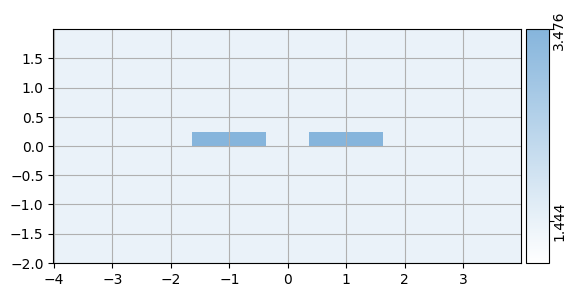

In [31]:
mw.visualize(css[2])

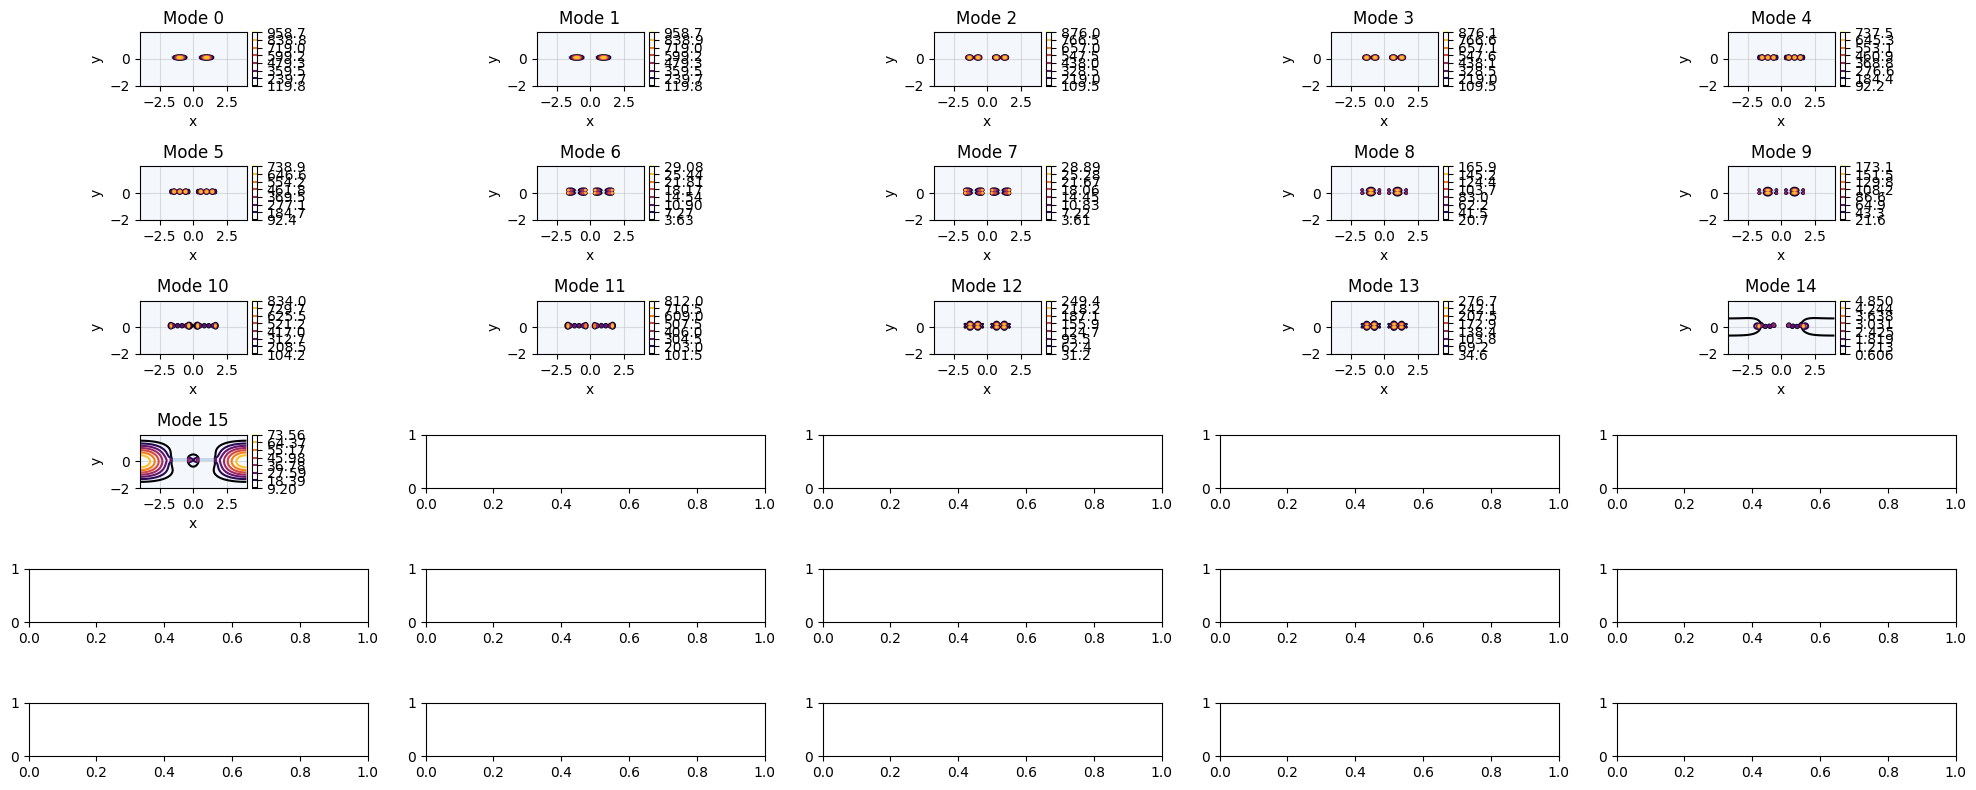

In [75]:
import matplotlib.pyplot as plt

# 1. Save the original plt.show function
original_show = plt.show

# 2. Define a dummy function that does nothing
def dummy_show(*args, **kwargs):
    pass

# 3. Replace plt.show with our dummy
plt.show = dummy_show

try:
    fig, axes = plt.subplots(6, 5, figsize=(20, 8))
    axes_flat = axes.flatten()

    for mode_nr in range(16):
        ax = axes_flat[mode_nr]
        plt.sca(ax) # Set current axis for the library to find
        
        # This call will now NOT pop up a window or reset the figure
        mw.visualize(modes[2][mode_nr], fields=["Ex"])
        
        ax.set_title(f"Mode {mode_nr}")

    plt.tight_layout()

finally:
    # 4. CRITICAL: Restore the real plt.show
    plt.show = original_show

# 5. Now manually call the real show once to see the grid
plt.show()

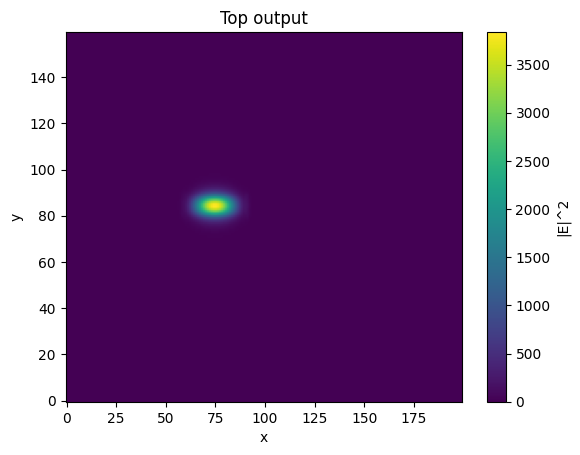

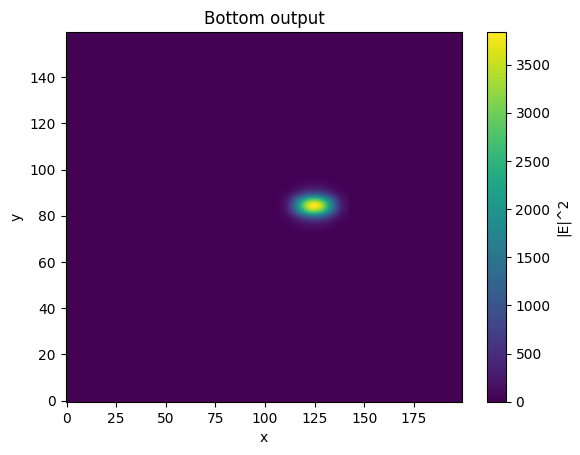

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_field(mode, component="Ez", x=None, y=None, title=None):


    if component == "intensity":
        data = (
            np.abs(mode.Ex)**2 +
            np.abs(mode.Ey)**2 +
            np.abs(mode.Ez)**2
        )
        label = "|E|^2"
    else:
        data = getattr(mode, component)
        data = np.real(data)  # or np.abs(...) if you prefer
        label = component

    plt.figure()

    if x is not None and y is not None:
        extent = [x.min(), x.max(), y.min(), y.max()]
    else:
        extent = None

    plt.imshow(
        data.T,
        origin="lower",
        aspect="auto",
        extent=extent
    )

    plt.colorbar(label=label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title or f"{component} field")

    plt.show()


mode_s = out_modes[0] + out_modes[1]
mode_d = out_modes[0] - out_modes[1]

plot_field(mode_s, component="intensity", title="Top output")
plot_field(mode_d, component="intensity", title="Bottom output")

(1000, 200) (200,)


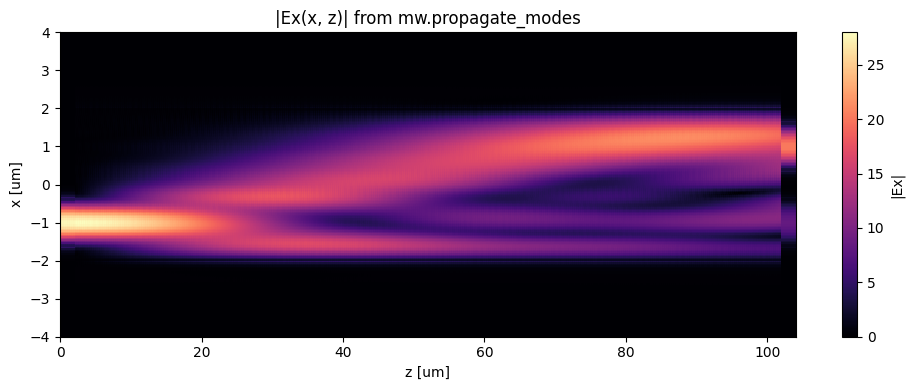

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Launch condition
# excite first mode on left input
# ----------------------------


# ----------------------------
# Propagate fields through cells
# ----------------------------
z = np.linspace(cells[0].z_min, cells[-1].z_max, 1000)
y = 0.0
field, x = mw.propagate_modes(modes, cells, y=y, z=z)

# ----------------------------
# Visualize field in each cell
# ----------------------------
print(field.shape, x.shape)
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(z, x, np.abs(field).T, shading="auto", cmap="magma")
ax.set_xlabel("z [um]")
ax.set_ylabel("x [um]")
ax.set_title("|Ex(x, z)| from mw.propagate_modes")
plt.colorbar(im, ax=ax, label="|Ex|")
plt.tight_layout()

If the propagated output field is

$$
a_1 E_1 + a_2 E_2
$$

and your two modes of interest are

$$
u_+ = \frac{E_1+E_2}{\sqrt{2}},\qquad
u_- = \frac{E_1-E_2}{\sqrt{2}},
$$

then the coefficients in that new basis are just the same basis change applied to $(a_1,a_2)$. Because MEOW represents transverse fields as linear combinations of eigenmodes with modal amplitudes, you can work directly with the coefficients as long as the modes are orthonormalized in the same inner product used by the solver. 

So the amplitudes into your two “port-like” combinations are

$$
c_+ = \frac{a_1+a_2}{\sqrt{2}},\qquad
c_- = \frac{a_1-a_2}{\sqrt{2}}.
$$

Then the coupling efficiencies are estimated from the powers in those amplitudes:

$$
\eta_+ = |c_+|^2,\qquad
\eta_- = |c_-|^2.
$$

If $E_1$ and $E_2$ are orthonormal and normalized to unit power in the same metric, this is the right direct estimate. MEOW’s algorithm notes explicitly say that when modes are orthonormalized in the same inner product, the metric becomes the identity, and then the simple coefficient formulas apply directly. 



In [6]:
forwards, backwards = mw.propagate_modes_coefficients(modes, cells, y=y, z=z)
forwards

[array([1.+0.j]),
 array([ 5.28491338e-01+9.91826736e-02j,  3.89126881e-01+7.30345330e-02j,
         3.47378433e-01+6.51832823e-02j, -9.48060358e-03-1.77857218e-03j,
        -3.03918610e-01-5.70017549e-02j, -3.73916302e-01-7.01086496e-02j,
        -2.22991589e-01-4.17959004e-02j, -1.50907848e-02-2.82752954e-03j,
         1.85558300e-01+3.47530364e-02j, -2.09154940e-01-3.91575787e-02j,
        -1.53447785e-05-2.89308382e-06j,  1.04657760e-05+1.96298799e-06j]),
 array([-0.30455136+0.10316971j,  0.26410322+0.36873226j])]

In [ ]:
def compute_metrics(S):
    c1 = (S[1, 0] + S[2, 0]) / np.sqrt(2)
    c2 = (S[1, 0] - S[2, 0]) / np.sqrt(2)
    
    P1 = (np.abs(c1) ** 2)
    P2 = (np.abs(c2) ** 2)
    Ptot = (sum(np.abs(S[0,:]) ** 2))
    return P1, P2, Ptot

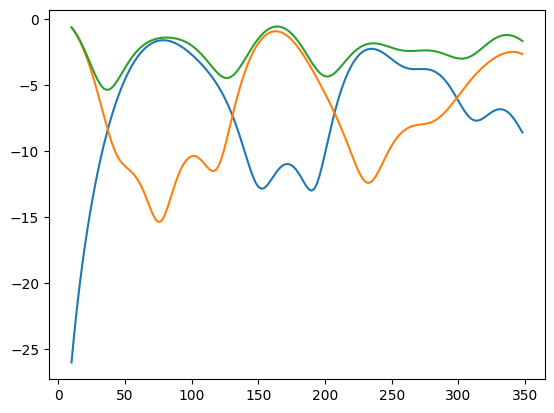

In [80]:
import pandas as pd

def lin2db(x):
    return 10 * np.log10(abs(x))

def compute_coupler_outputs(S):
    S1m = S[1, 0]
    S2m = S[2, 0]
    S21 = (S1m - S2m) / np.sqrt(2)
    S31 = (S1m + S2m) / np.sqrt(2)
    P1 = 2 * lin2db(S21)
    P2 = 2 * lin2db(S31)
    P = lin2db(abs(S21) ** 2 + abs(S31) ** 2)
    return P1, P2, P

lengths = np.arange(10., 350., 2.)

P1, P2, Ptot = [], [], []
for length in lengths:
    cell_lengths = [2., length, 2.]

    S, port_map = mw.compute_s_matrix(modes, cells=cells, cell_lengths=cell_lengths)
    

    p1, p2, ptot = compute_coupler_outputs(S)
    
    P1.append(p1)
    P2.append(p2)
    Ptot.append(ptot)

plt.plot(lengths, P1)
plt.plot(lengths, P2)
plt.plot(lengths, Ptot)


In [79]:
np.abs(S) ** 2

array([[9.40136634e-05, 3.94744453e-01, 2.86234651e-01, 1.78696247e-02,
        1.85383676e-04, 2.75052942e-02, 1.08376600e-01, 1.13909762e-10,
        1.03500953e-09, 3.42930166e-09, 3.57429661e-09, 6.05477650e-04,
        3.39511562e-04, 8.69395633e-10, 1.21681205e-08],
       [3.94744453e-01, 4.52641940e-06, 4.07540578e-06, 5.40599916e-07,
        1.25580895e-08, 9.38825643e-06, 8.14292637e-06, 1.17371688e-14,
        1.10321048e-13, 5.46923262e-13, 2.71339363e-11, 2.99546040e-07,
        1.06725065e-09, 2.58744034e-14, 7.77201988e-11],
       [2.86234651e-01, 4.07540578e-06, 8.13520127e-06, 2.54433926e-07,
        9.84939741e-09, 4.35446031e-06, 4.56373682e-06, 2.31909539e-13,
        1.82142209e-13, 6.99877704e-11, 2.19537736e-13, 3.43434242e-07,
        7.39923229e-07, 2.74787749e-12, 2.35457565e-13],
       [1.78696247e-02, 5.40599916e-07, 2.54433926e-07, 5.61525090e-06,
        1.72612409e-09, 1.86669407e-07, 6.23930883e-07, 3.78331147e-16,
        1.83135478e-11, 6.29631893e-1

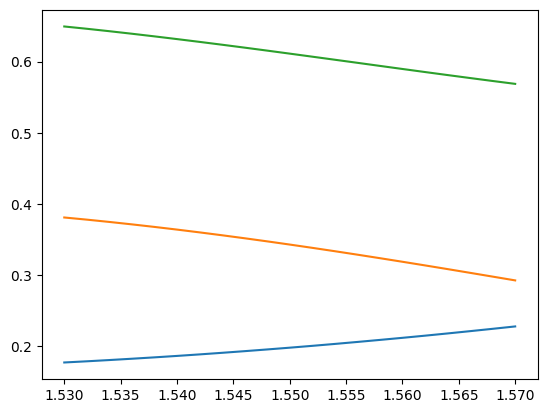

In [ ]:
L = 300
wl0 = 1.55
wl_range = 0.04
dwl = 0.002

wavelengths = np.arange(wl0 - wl_range/2, wl0 + wl_range/2, dwl)

P1, P2, Ptot = [], [], []
for wl in wavelengths:
    env = mw.Environment(wl=wl, T=T)
    css = [mw.CrossSection.from_cell(cell=c, env=env) for c in cells]

    modes = [
        mw.compute_modes(css[0], num_modes=1),
        mw.compute_modes(css[1], num_modes=20),
        mw.compute_modes(css[2], num_modes=4),
    ]

    
    cell_lengths = [2., L, 2.]

    S, port_map = mw.compute_s_matrix(modes, cells=cells, cell_lengths=cell_lengths)
    c1 = (S[1, 0] + S[2, 0]) / np.sqrt(2)
    c2 = (S[1, 0] - S[2, 0]) / np.sqrt(2)

    P1.append(np.abs(c1) ** 2)
    P2.append(np.abs(c2) ** 2)
    Ptot.append(sum(np.abs(S[0,:]) ** 2))

plt.plot(wavelengths, P1)
plt.plot(wavelengths, P2)
plt.plot(wavelengths, Ptot)

In [21]:
modes[1][1].neff, modes[1][0].neff

(array(2.82897439+0.j), array(2.83879766+0.j))

In [1]:
import pandas as pd
import numpy as np

# --- Analytical Model:  ---
def effective_width_model(W_um, lambda_0_um, n_core, n_clad):
    delta = (lambda_0_um / (2 * np.pi)) / np.sqrt(n_core**2 - n_clad**2)
    return W_um + 2 * delta

def lpi_from_effective_width_model(n_r, n_core, n_clad, W_um):
    """
    Returns a function L_pi_model(lambda_0) that uses effective width approximation.
    """
    def model(lambda_0_um):
        W_eff = effective_width_model(W_um, lambda_0_um, n_core, n_clad)
        return (4 * n_r * W_eff**2) / (3 * lambda_0_um)
    return model

# --- Simulation-based Model ---
def lpi_from_simulation(n0, n1):
    """
    Returns a function L_pi_model(lambda_0) using simulated effective indices.
    """
    def model(lambda_0_um):
        return lambda_0_um / (2 * (n0 - n1))
    return model

# --- Core Function ---
def compute_mmi_lengths(lambda_0_um, L_pi_model):
    """
    Compute MMI lengths given only lambda_0 and an L_pi model function.
    
    Parameters:
    - lambda_0_um: wavelength in microns
    - L_pi_model: function that takes lambda_0 and returns L_pi
    
    Returns:
    - DataFrame of MMI imaging lengths.
    """
    L_pi = L_pi_model(lambda_0_um)

    # Derived lengths
    lengths = {
        "L_pi (model output)": L_pi,
        "1x2 imaging (symmetric)": 3 * L_pi / 8,
        "2x2 3dB (general)": 1.5 * L_pi,
        "2x2 cross (general)": 3 * L_pi,
        "2x2 3dB (paired)": 0.5 * L_pi,
        "2x2 cross (paired)": L_pi,
        
    }

    df = pd.DataFrame({
        "Parameter": list(lengths.keys()),
        "Length (µm)": [round(val, 3) for val in lengths.values()]
    })

    return df




In [23]:
wl = 1.55
W = 3
nclad = 1.44
ncore = 3.47
neff1 = modes[1][0].neff.real
neff2 = modes[1][1].neff.real


params_analytical = (2.34, ncore, nclad, W)
params_sim = (neff1, neff2)


print("Analytical model")
display(compute_mmi_lengths(wl, lpi_from_effective_width_model(*params_analytical)))
print("Simulation model")
display(compute_mmi_lengths(wl, lpi_from_simulation(*params_sim)))

Analytical model


,Parameter,Length (µm)
0,L_pi (model output),20.053
1,1x2 imaging (symmetric),7.520
2,2x2 3dB (general),30.079
3,2x2 cross (general),60.158
4,2x2 3dB (paired),10.026
5,2x2 cross (paired),20.053


Simulation model


,Parameter,Length (µm)
0,L_pi (model output),78.894
1,1x2 imaging (symmetric),29.585
2,2x2 3dB (general),118.341
3,2x2 cross (general),236.683
4,2x2 3dB (paired),39.447
5,2x2 cross (paired),78.894
